In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def format_input(question, options):
    # Format the input prompt
    prompt = f"Question: {question}\n"
    for label, text in options.items():
        prompt += f"({label}) {text}\n"
    prompt += "Answer:"

    return prompt

def attention_heatmap(model, tokenizer, prompt, correct_answer, num_layers_to_show=None, num_heads_to_show=1):
    # Tokenize input
    full_input = prompt + " " + correct_answer
    inputs = tokenizer(full_input, return_tensors="pt")

    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True, return_dict=True)
    attentions = outputs.attentions  # List of tensors (batch, heads, seq, seq)

    total_layers = len(attentions)
    if num_layers_to_show is None:
        num_layers_to_show = total_layers

    # Check total heads
    total_heads = attentions[0].shape[1]
    if num_heads_to_show > total_heads:
        raise ValueError(f"Model only has {total_heads} heads per layer.")

    answer_token_idx = inputs["input_ids"].shape[1] - 1
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    # Setup grid of subplots
    fig, axs = plt.subplots(
        num_layers_to_show,
        num_heads_to_show,
        figsize=(4 * num_heads_to_show + 2, 3 * num_layers_to_show),
        squeeze=False,
    )

    for layer_idx in range(num_layers_to_show):
        attn_layer = attentions[layer_idx][0]  # (heads, seq, seq)
        for head_idx in range(num_heads_to_show):
            head_attn = attn_layer[head_idx]  # (seq, seq)
            attn_weights = head_attn[answer_token_idx].cpu().numpy()

            ax = axs[layer_idx][head_idx]
            sns.heatmap(
                [attn_weights], xticklabels=tokens, cmap="viridis", cbar=True, ax=ax
            )
            ax.set_xticklabels(tokens, rotation=90)
            ax.set_title(f"Layer {layer_idx + 1}, Head {head_idx}")

    plt.tight_layout()
    plt.show()


In [3]:
# Load Qwen model
model_name = "Qwen/Qwen3-0.6B-Base"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)
model.eval()

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
        (post_attention_layernorm): Qwe

In [ ]:
def get_model_attention_structure(model, tokenizer):
    dummy_text = "The capital of France is Paris."
    inputs = tokenizer(dummy_text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True, return_dict=True)
    
    # Get attention tensor list: one tensor per layer
    attentions = outputs.attentions

    num_layers = len(attentions)
    num_heads = attentions[0].shape[1]  # shape: (batch, heads, seq, seq)

    print(f"🧱 Number of transformer layers: {num_layers}")
    print(f"🧠 Number of attention heads per layer: {num_heads}")

    return num_layers, num_heads


num_layers, num_heads = get_model_attention_structure(model, tokenizer)

`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


🧱 Number of transformer layers: 28
🧠 Number of attention heads per layer: 16


(28, 16)

In [5]:
# Prepare a single MCQA example
question = "Why does ice float on water?"
options = {
    "A": "Because it is denser than water",
    "B": "Because it is less denser than water",
    "C": "Because it has a different chemical structure",
    "D": "Because of surface tension"
}
correct_answer = "B"

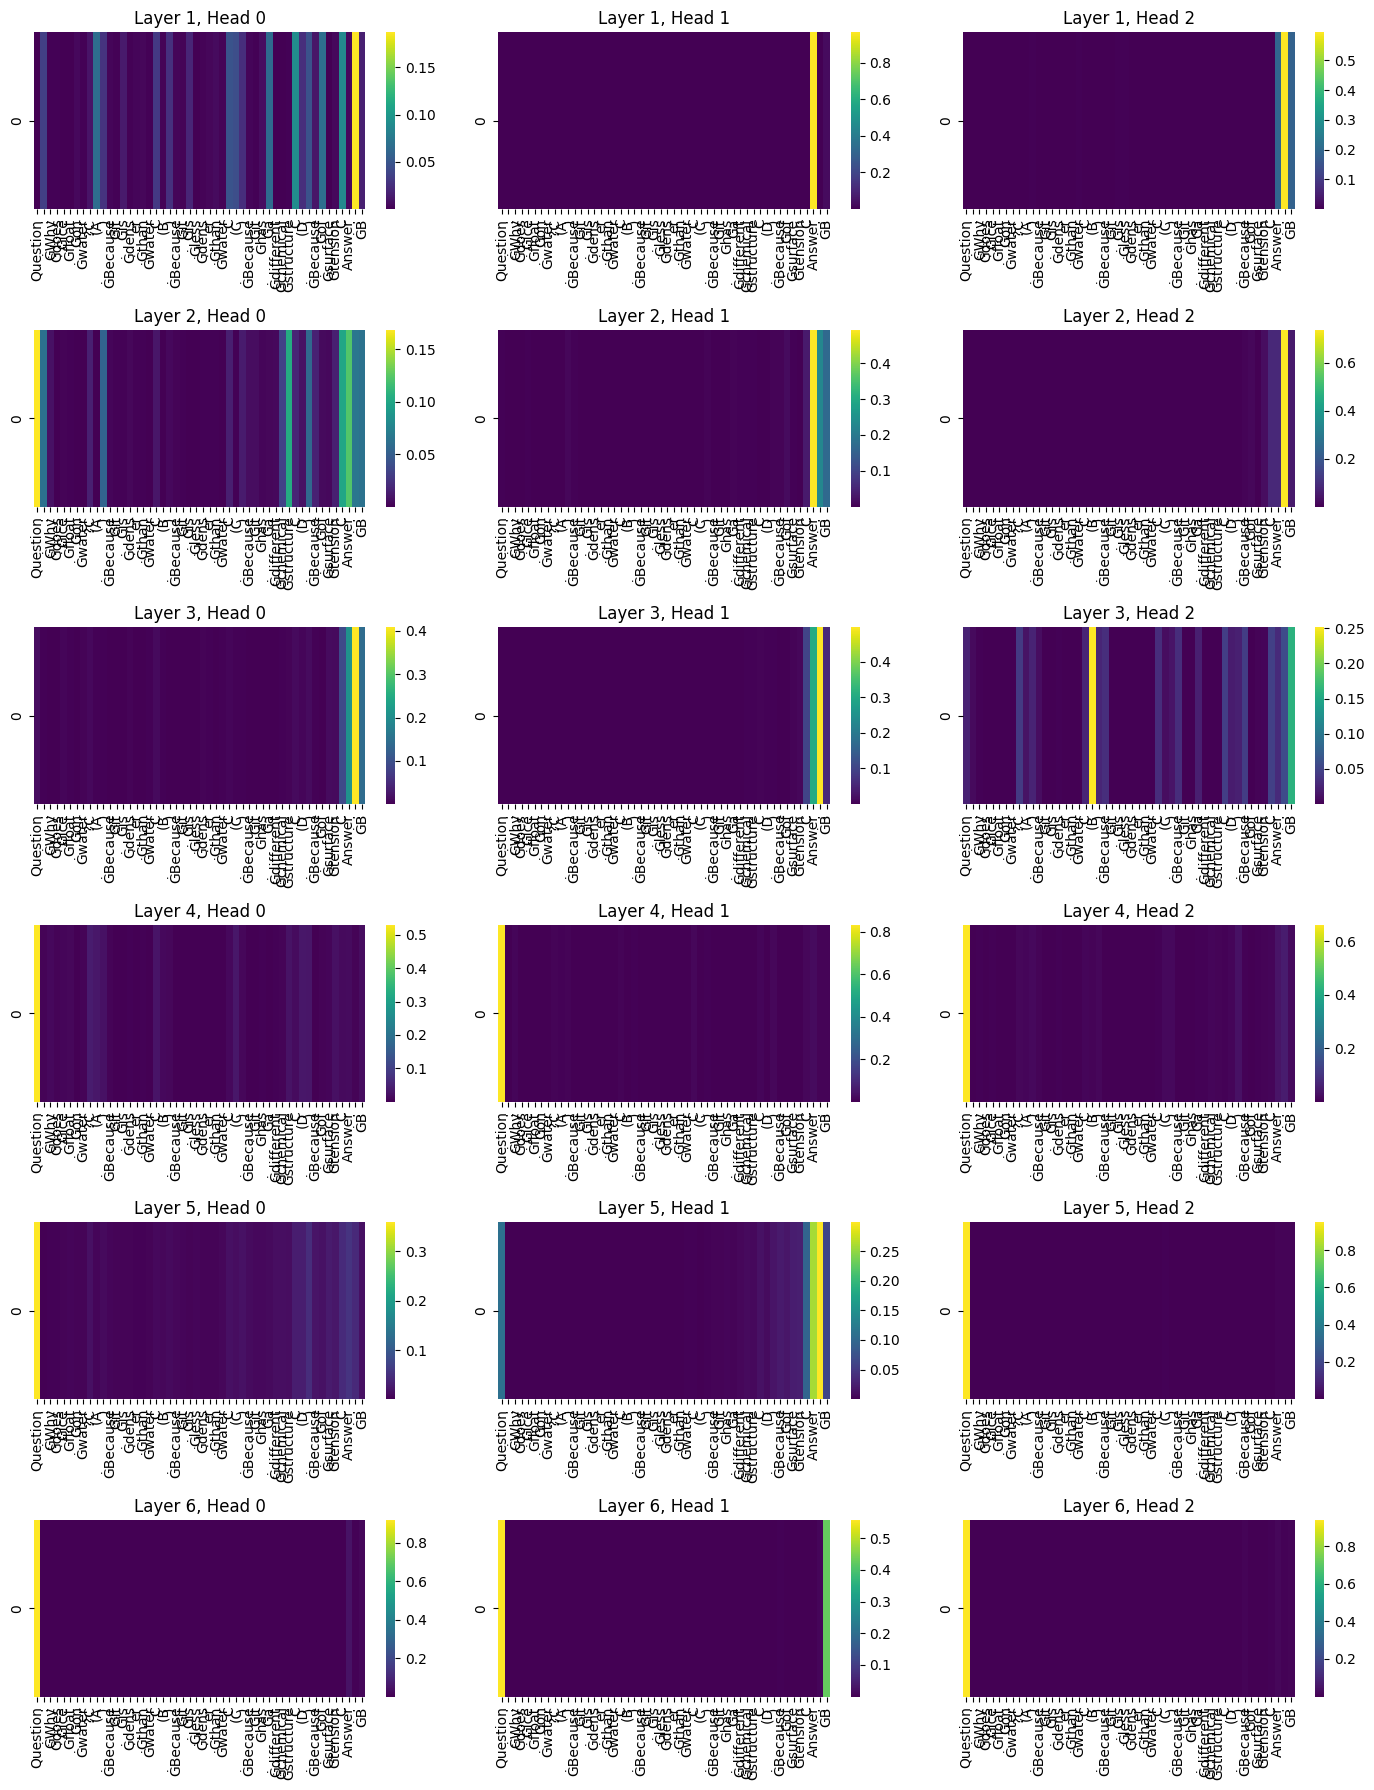

In [6]:
formatted_input = format_input(question, options)

attention_heatmap(model, tokenizer, formatted_input, correct_answer, 6, 3)

In [4]:
# Load Qwen model
model_name = "andresnowak/MNLP_M2_mcqa_model"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)
model.eval()

tokenizer_config.json:   0%|          | 0.00/5.43k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/785 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024, padding_idx=151654)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
        (post_atten

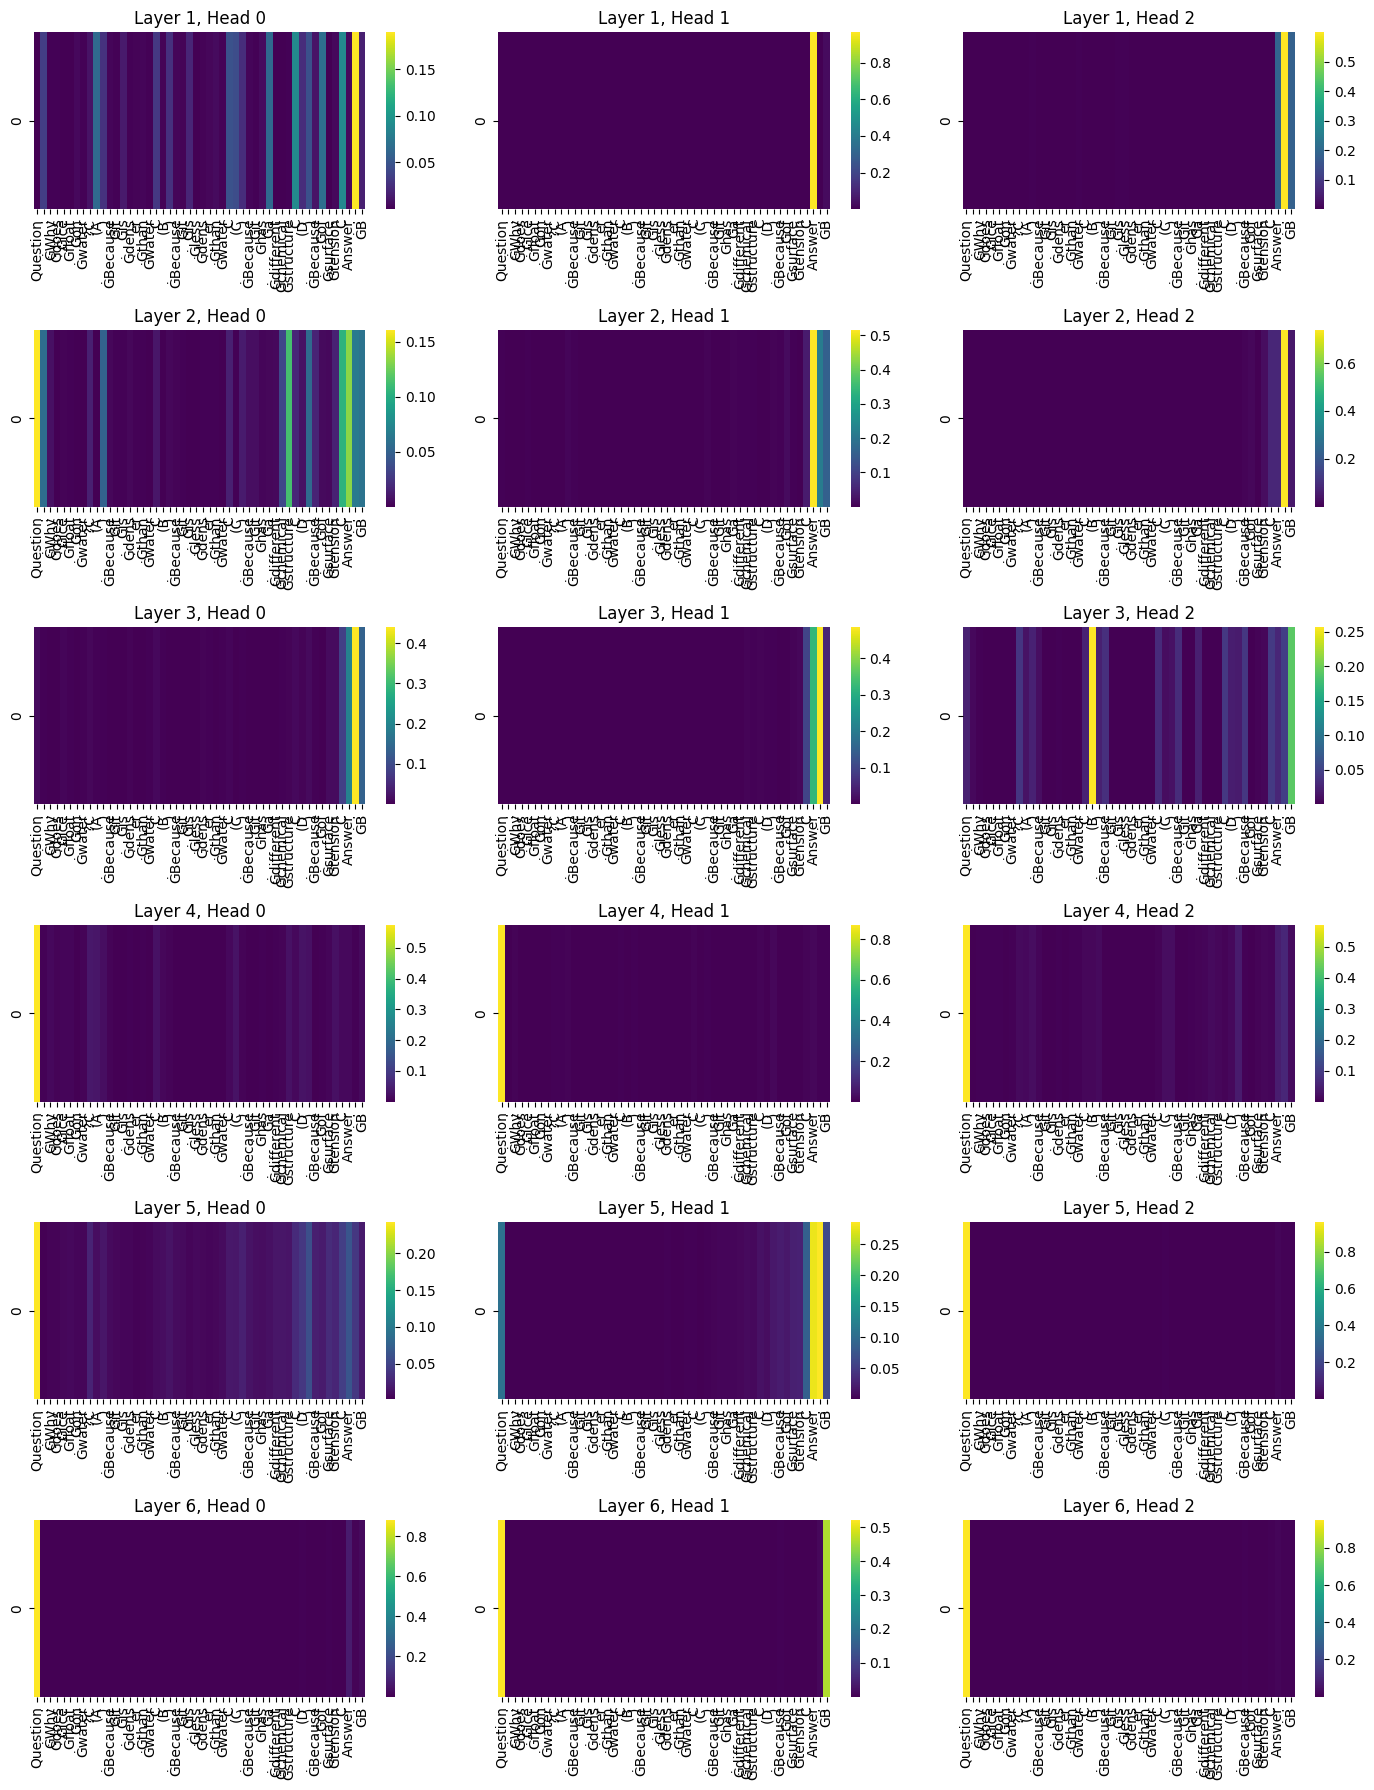

In [11]:
formatted_input = format_input(question, options)

attention_heatmap(model, tokenizer, formatted_input, correct_answer, 6, 3)

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM

def compare_attention(
    base_model_name: str,
    finetuned_model_name: str,
    prompt: str,
    correct_answer: str,
    layers_to_show: list,
    heads_to_show: list,
    device: str = "mps"
):
    """
    Compare attention of base_model versus finetuned_model on a single MCQA example.
    
    Args:
      - base_model_name: HuggingFace ID for the base Qwen model.
      - finetuned_model_name: HuggingFace ID (or local path) for the fine-tuned Qwen.
      - prompt: Full prompt string up to "Answer:" (without the actual answer).
      - correct_answer: The letter (e.g. "B") that you want to force‐feed as the model's answer.
      - layers_to_show: list of layer indices (0-based) you want to visualize.
      - heads_to_show: list of head indices (0-based) you want to visualize per layer.
      - device: "cpu" or "cuda".
    """
    # 1. Load tokenizer and both models
    tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
    
    # Base model
    model_A = AutoModelForCausalLM.from_pretrained(base_model_name, trust_remote_code=True)
    model_A.to(device).eval()
    
    # Fine‐tuned model (same architecture, just different weights)
    model_B = AutoModelForCausalLM.from_pretrained(finetuned_model_name, trust_remote_code=True)
    model_B.to(device).eval()
    
    # 2. Build full input (prompt + forced answer)
    full_input = prompt.strip() + " " + correct_answer
    inputs = tokenizer(full_input, return_tensors="pt").to(device)
    
    # 3. Forward pass both models with attentions
    with torch.no_grad():
        out_A = model_A(**inputs, output_attentions=True, return_dict=True)
        out_B = model_B(**inputs, output_attentions=True, return_dict=True)
    
    attn_list_A = out_A.attentions  # length = num_layers, each shape (1, H, T, T)
    attn_list_B = out_B.attentions
    
    # 4. Identify the position of the forced‐answer token
    #    Assumes model used the same tokenization; last token is the answer token.
    answer_idx = inputs["input_ids"].shape[1] - 1  # scalar
    
    # 5. Convert IDs→tokens once (shared by both models)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    T = len(tokens)
    
    # 6. For each (layer ℓ, head h), extract the row of size T from both models
    #    and compute an L1 difference. Then plot side‐by‐side heatmaps.
    for layer in layers_to_show:
        num_heads = attn_list_A[layer].shape[1]  # should be same for A and B
        if layer >= len(attn_list_A) or layer >= len(attn_list_B):
            raise ValueError(f"Layer {layer} out of range (model has {len(attn_list_A)} layers).")
        
        for h in heads_to_show:
            if h >= num_heads:
                raise ValueError(f"Head {h} out of range (layer {layer} has {num_heads} heads).")
            
            # attention matrices: shape (1, H, T, T)
            M_A = attn_list_A[layer][0, h]  # shape (T, T)
            M_B = attn_list_B[layer][0, h]
            
            # Extract answer row: size T
            vec_A = M_A[answer_idx].cpu().numpy()
            vec_B = M_B[answer_idx].cpu().numpy()
            
            # Compute L1 diff
            L1_diff = float(torch.norm(M_A[answer_idx] - M_B[answer_idx], p=1).item())  # Example: Detect if attention is overconfidently focused on different tokens.
            # Compute cosine similarity: cos(u,v) = (u·v)/(||u||·||v||)
            cos_sim = (
                (vec_A @ vec_B)
                / ( (vec_A @ vec_A)**0.5 * (vec_B @ vec_B)**0.5 + 1e-12 )
            )
            
            # 7. Plot side‐by‐side heatmaps with same color scale
            vmax = max(vec_A.max(), vec_B.max())
            vmin = min(vec_A.min(), vec_B.min())
            
            fig, axes = plt.subplots(
                1, 2, figsize=(12, 3),
                sharey=True, sharex=True
            )
            # Heatmap for Model A
            sns.heatmap(
                [vec_A],
                xticklabels=tokens,
                yticklabels=[f"Layer {layer+1}, Head {h}\n(Base)"],
                cmap="viridis", vmin=vmin, vmax=vmax,
                cbar=True,
                ax=axes[0]
            )
            axes[0].set_xticklabels(tokens, rotation=90)
            axes[0].set_ylabel("")  # we put label in yticklabels
            
            # Heatmap for Model B
            sns.heatmap(
                [vec_B],
                xticklabels=tokens,
                yticklabels=[f"Layer {layer+1}, Head {h}\n(Finetuned)"],
                cmap="viridis", vmin=vmin, vmax=vmax,
                cbar=True,
                ax=axes[1]
            )
            axes[1].set_xticklabels(tokens, rotation=90)
            
            # Title including quantitative metrics
            fig.suptitle(
                f"Layer {layer+1}, Head {h}  |  L1 diff = {L1_diff:.4f}  |  Cosine sim = {cos_sim:.4f}",
                fontsize=12
            )
            plt.tight_layout(rect=[0, 0, 1, 0.85])
            plt.show()


In [14]:
layers_to_show = [2, 4, 8, 10]  # e.g. [21,22,23] if there are 24 layers
heads_to_show  = [0, 1, 2, 3]

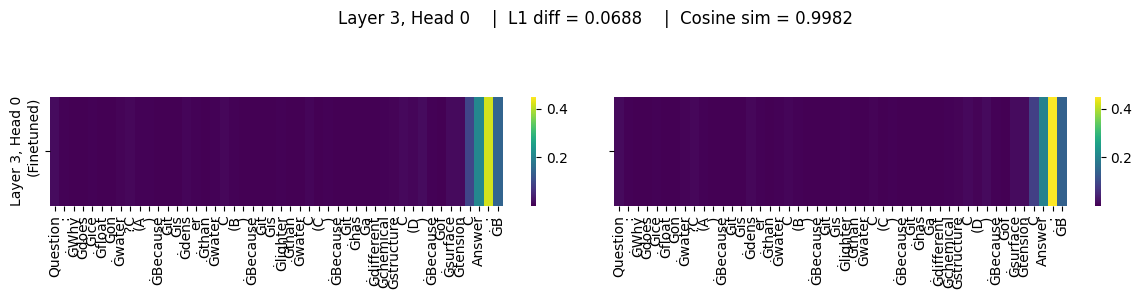

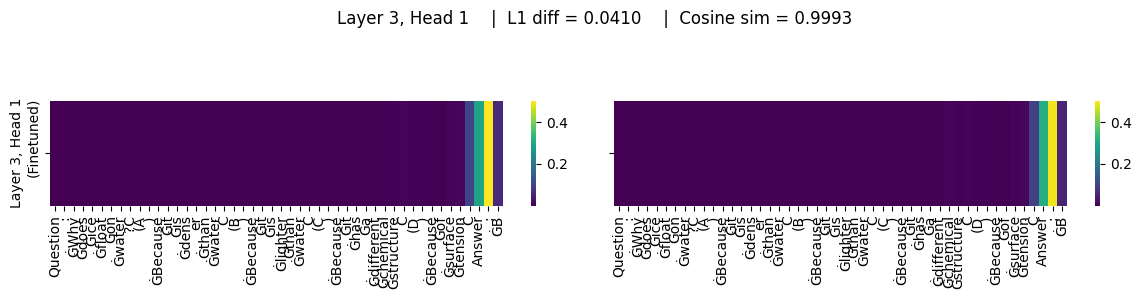

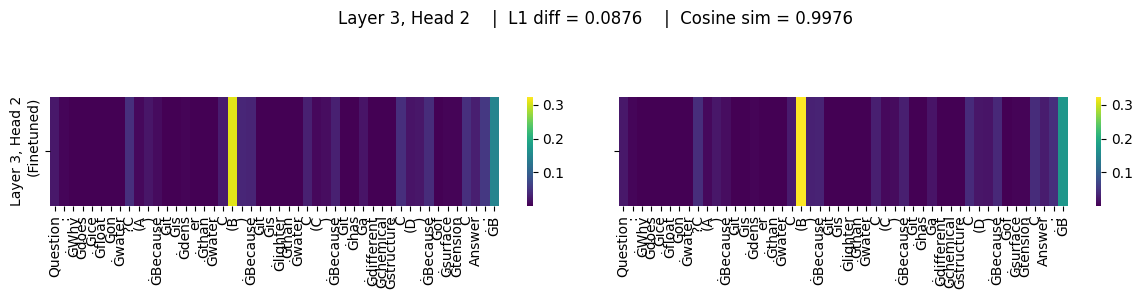

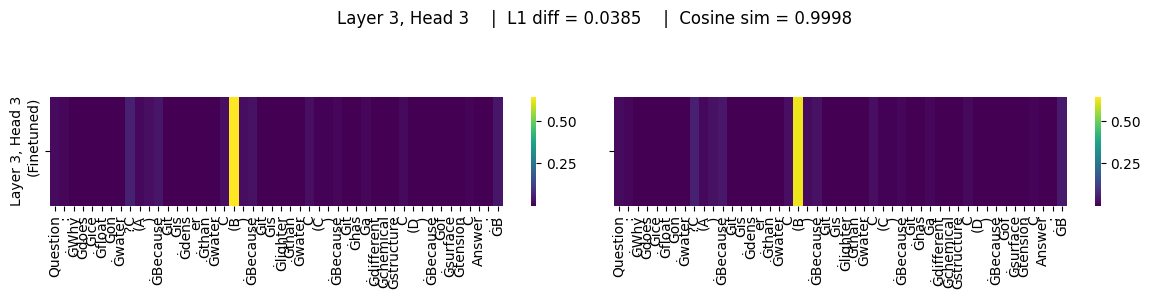

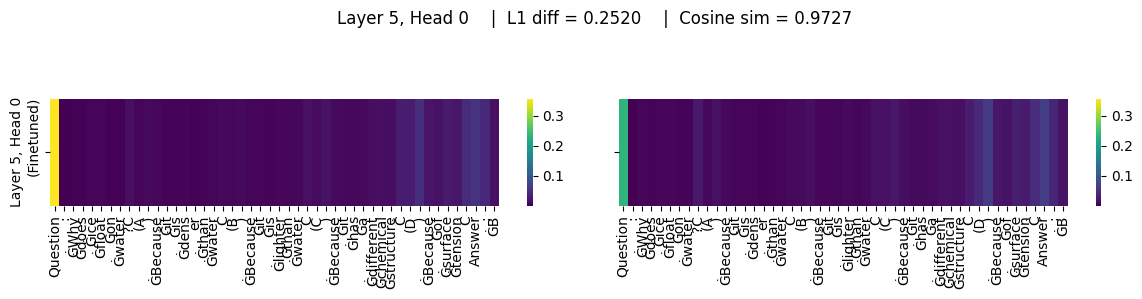

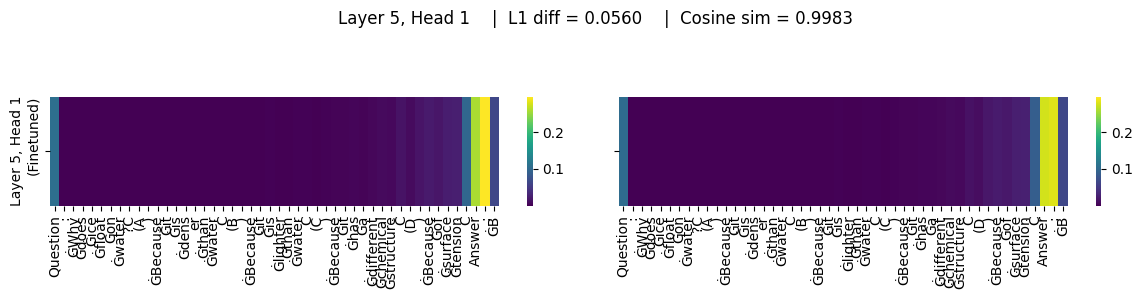

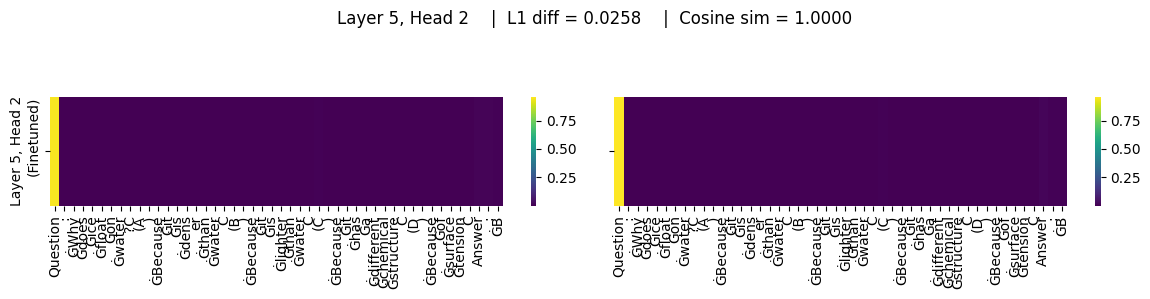

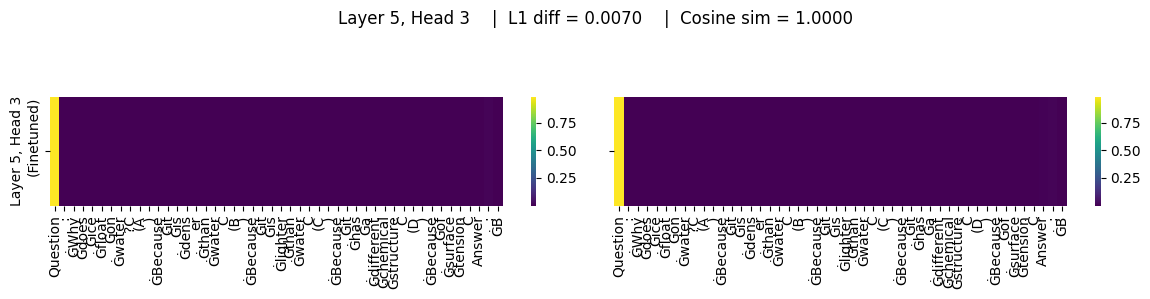

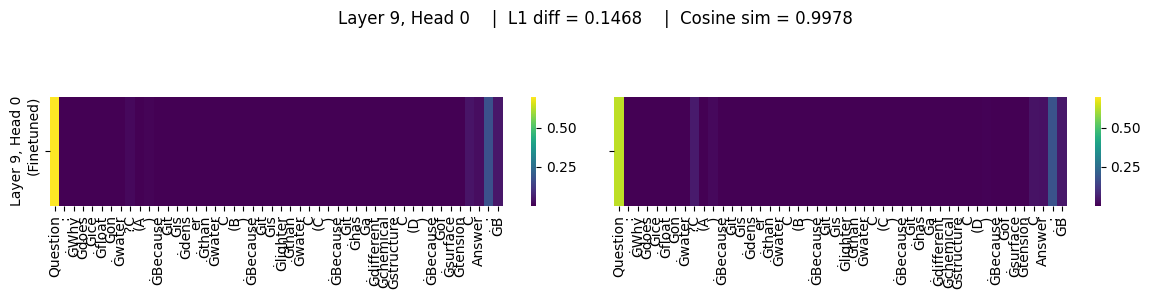

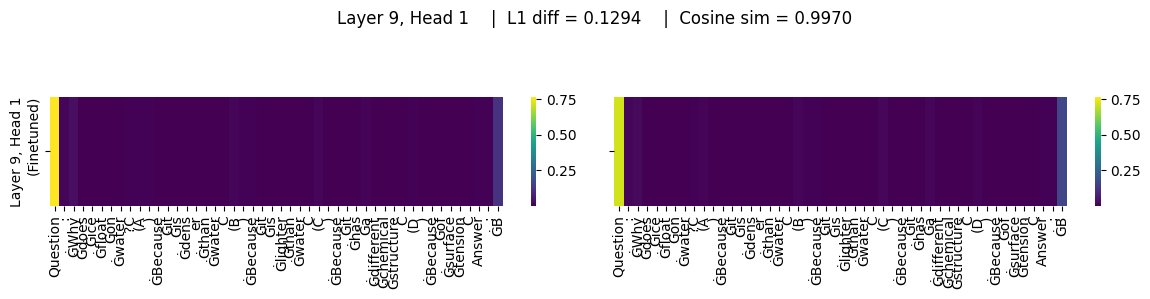

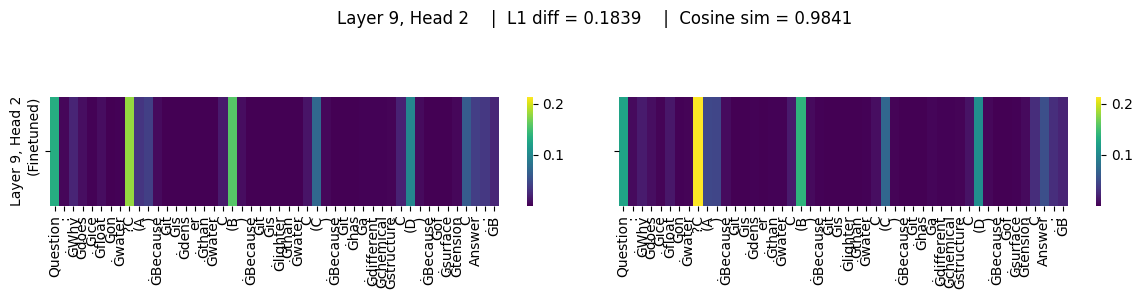

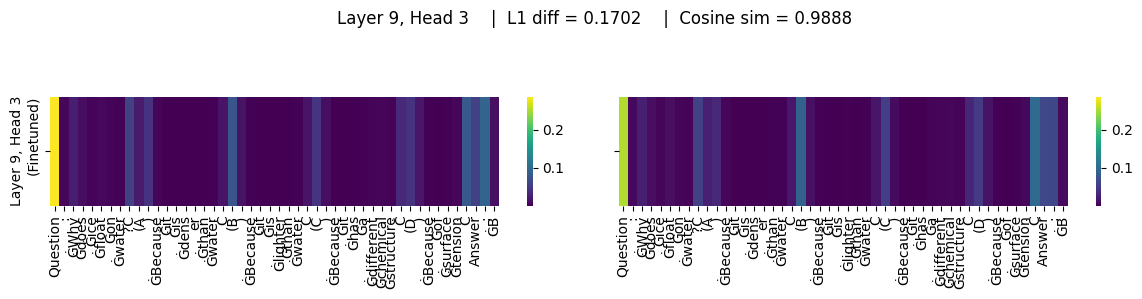

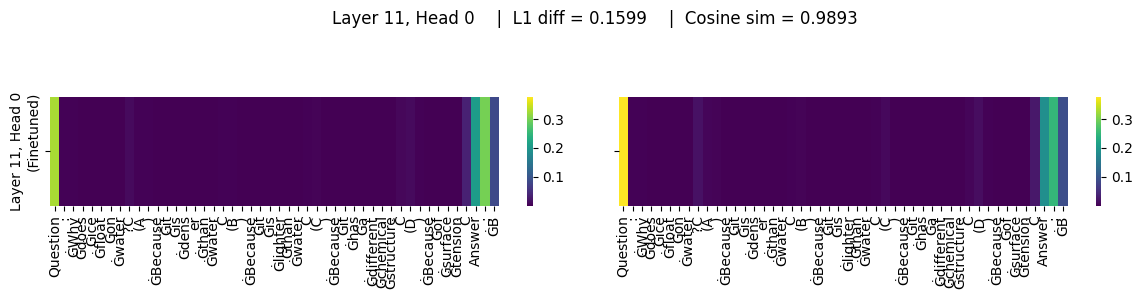

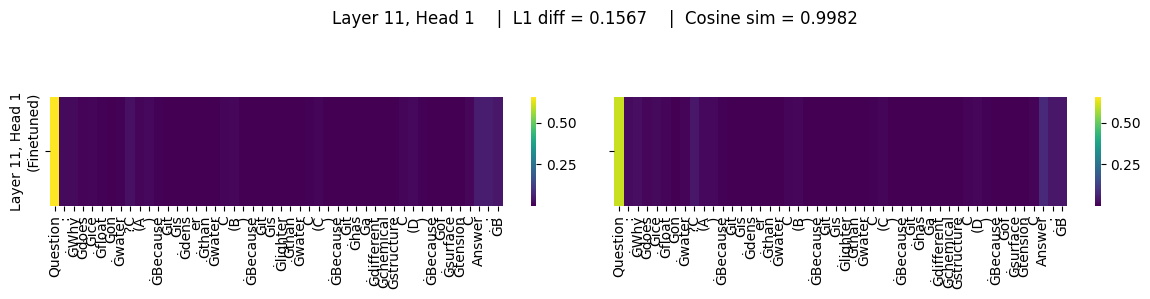

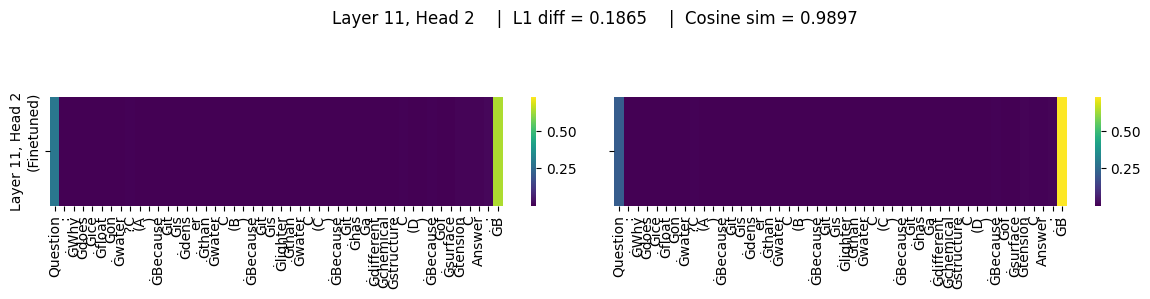

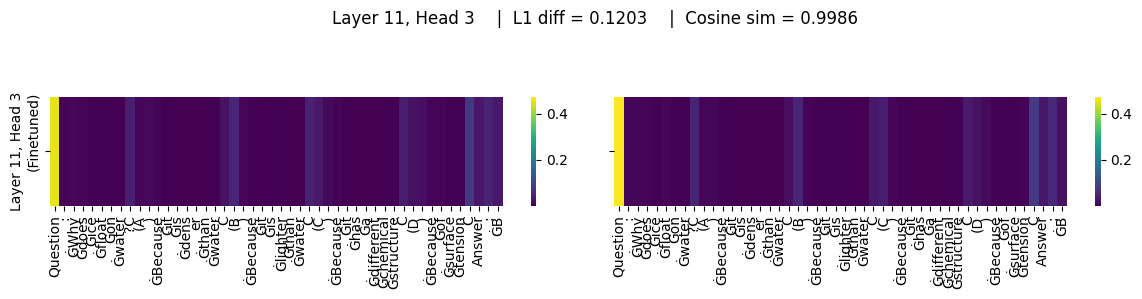

In [15]:
prompt = """Question: Why does ice float on water?
(A) Because it is denser than water
(B) Because it is lighter than water
(C) Because it has a different chemical structure
(D) Because of surface tension
Answer:"""
correct_answer = "B"

compare_attention(
    base_model_name="Qwen/Qwen3-0.6B-Base",
    finetuned_model_name="andresnowak/MNLP_M2_mcqa_model",
    prompt=prompt,
    correct_answer=correct_answer,
    layers_to_show=layers_to_show,
    heads_to_show=heads_to_show,
    device="mps",  # or "cpu"
)

In [ ]:
import torch
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModelForCausalLM


def compare_llms(model1_name, model2_name):
    model1 = AutoModelForCausalLM.from_pretrained(model1_name, trust_remote_code=True)
    model2 = AutoModelForCausalLM.from_pretrained(model2_name, trust_remote_code=True)
    # Extract and flatten all parameters (excluding biases)
    θ1 = torch.cat(
        [p.flatten() for n, p in model1.named_parameters() if "bias" not in n]
    )
    θ2 = torch.cat(
        [p.flatten() for n, p in model2.named_parameters() if "bias" not in n]
    )

    # Normalize to mean=0, std=1 (for scale invariance)
    θ1, θ2 = (θ1 - θ1.mean()) / θ1.std(), (θ2 - θ2.mean()) / θ2.std()

    # Compute metrics
    l2_dist = torch.norm(θ1 - θ2, p=2).item()
    cos_sim = 1 - cosine(
        θ1.numpy(), θ2.numpy()
    )  # Scipy's cosine is faster for large vectors

    return {"l2_distance": l2_dist, "cosine_similarity": cos_sim}

compare_llms(
    model1_name="Qwen/Qwen3-0.6B-Base",
    model2_name="andresnowak/MNLP_M2_mcqa_model",
)